#Generating a convex hull with the Divide-And-Conquer (DAC) algorithm

Name: Eunbi Cho\
Student ID: 22000724\
Date: June 09, 2023

## Generate 30 random points under conditions:
- no two points have same x coordinate
- no two points have same y coordinate
- no three points are in a line (collinear)

In [20]:
import random

def generate_valid_points(num_points):
    points = set()
    while len(points) < num_points:
        x = random.randint(1, 100)
        y = random.randint(1, 100)
        point = (x, y)
        valid = True
        for p in points:
            if p[0] == x or p[1] == y or is_collinear(p, point, points):
                valid = False
                break
        if valid:
            points.add(point)
    return list(points)

def is_collinear(p1, p2, points):
    x1, y1 = p1
    x2, y2 = p2
    for p3 in points:
        if p3 != p1 and p3 != p2:
            x3, y3 = p3
            if (y2 - y1) * (x3 - x2) == (y3 - y2) * (x2 - x1):
                return True
    return False

points = generate_valid_points(30)
points

[(39, 76),
 (97, 81),
 (15, 33),
 (21, 77),
 (93, 59),
 (88, 48),
 (73, 44),
 (20, 41),
 (23, 43),
 (4, 42),
 (98, 94),
 (82, 83),
 (1, 27),
 (78, 67),
 (64, 92),
 (61, 14),
 (30, 69),
 (37, 87),
 (52, 78),
 (56, 100),
 (79, 16),
 (41, 29),
 (65, 90),
 (27, 54),
 (47, 8),
 (100, 23),
 (55, 24),
 (5, 32),
 (48, 61),
 (49, 60)]

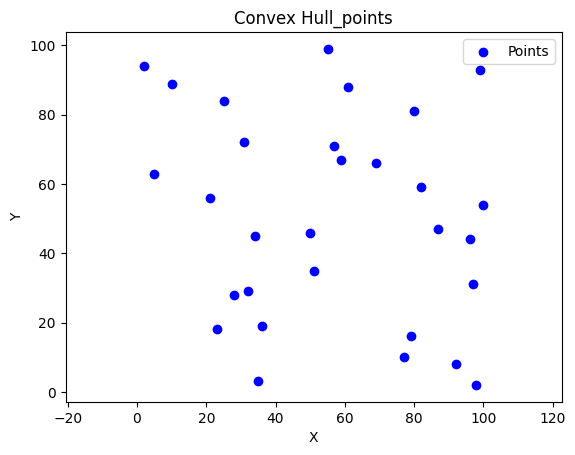

In [21]:
#visualization
import matplotlib.pyplot as plt

def plot_convex_hull(points):
    # Separate the x and y coordinates of the points and convex hull
    points_x = [p[0] for p in points]
    points_y = [p[1] for p in points]

    # Plot the points and convex hull
    plt.scatter(points_x, points_y, color='blue', label='Points')

    # Set the plot title and labels
    plt.title('Convex Hull_points')
    plt.xlabel('X')
    plt.ylabel('Y')

    # Set the aspect ratio to equal
    plt.axis('equal')

    # Display the legend
    plt.legend()

    # Show the plot
    plt.show()

points = generate_valid_points(30)
plot_convex_hull(points)

## Divide:
Sort the points by the 𝑥 coordinate and decompose the plane in two half-planes

In [22]:
def separate_half_planes(points):
    # Sort the points by x-coordinate
    points_sorted = sorted(points, key=lambda p: p[0])

    # Find the index where the half-plane changes
    mid_index = len(points_sorted) // 2

    # Separate the points into two half-planes
    half_plane1 = points_sorted[:mid_index]
    half_plane2 = points_sorted[mid_index:]

    return half_plane1, half_plane2

half_plane1, half_plane2 = separate_half_planes(points)
print("Half-Plane 1:", half_plane1)
print("Half-Plane 2:", half_plane2)

Half-Plane 1: [(2, 94), (5, 63), (10, 89), (21, 56), (23, 18), (25, 84), (28, 28), (31, 72), (32, 29), (34, 45), (35, 3), (36, 19), (50, 46), (51, 35), (55, 99)]
Half-Plane 2: [(57, 71), (59, 67), (61, 88), (69, 66), (77, 10), (79, 16), (80, 81), (82, 59), (87, 47), (92, 8), (96, 44), (97, 31), (98, 2), (99, 93), (100, 54)]


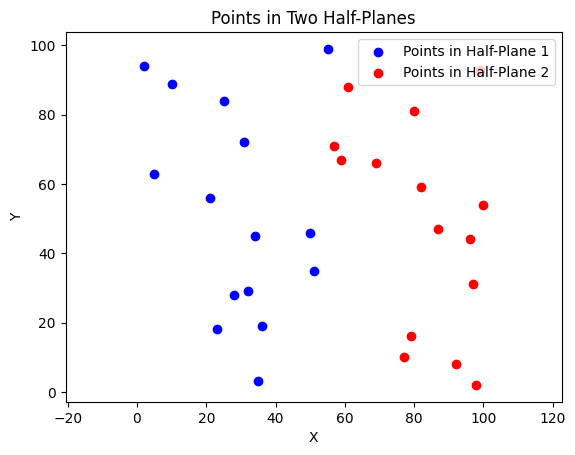

In [23]:
# visualization
def plot_half_planes(half_plane1, half_plane2):
    # Separate the x and y coordinates of the points in half-plane 1
    half_plane1_x = [p[0] for p in half_plane1]
    half_plane1_y = [p[1] for p in half_plane1]

    # Separate the x and y coordinates of the points in half-plane 2
    half_plane2_x = [p[0] for p in half_plane2]
    half_plane2_y = [p[1] for p in half_plane2]

    # Plot the points in two different colors representing the two half-planes
    plt.scatter(half_plane1_x, half_plane1_y, color='blue', label='Points in Half-Plane 1')
    plt.scatter(half_plane2_x, half_plane2_y, color='red', label='Points in Half-Plane 2')

    # Set the plot title and labels
    plt.title('Points in Two Half-Planes')
    plt.xlabel('X')
    plt.ylabel('Y')

    # Set the aspect ratio to equal
    plt.axis('equal')

    # Display the legend
    plt.legend()

    # Show the plot
    plt.show()

plot_half_planes(half_plane1, half_plane2)

## Conquer:
Generate a convex hull for the points on each half-plane

In [24]:

def generate_convex_hull(points):
    def get_orientation(origin, p1, p2):
        """
        Returns the orientation of p1 with regards to p2 using origin.
        Negative if p1 is clockwise of p2.
        :param p1: Point
        :param p2: Point
        :return: integer
        """
        difference = ((p2[0] - origin[0]) * (p1[1] - origin[1])) - ((p1[0] - origin[0]) * (p2[1] - origin[1]))
        return difference

    # Sort the points lexicographically by x-coordinate and then y-coordinate
    sorted_points = sorted(points, key=lambda p: (p[0], p[1]))

    # Get the leftmost point
    start = sorted_points[0]
    min_x = start[0]
    for p in sorted_points[1:]:
        if p[0] < min_x:
            min_x = p[0]
            start = p

    point = start
    hull_points = [start]

    far_point = None
    while far_point is not start:
        # Get the first point (initial max) to use for comparison
        p1 = None
        for p in sorted_points:
            if p is point:
                continue
            else:
                p1 = p
                break

        far_point = p1

        for p2 in sorted_points:
            if p2 is point or p2 is p1:
                continue
            else:
                direction = get_orientation(point, far_point, p2)
                if direction > 0:
                    far_point = p2

        hull_points.append(far_point)
        point = far_point

    return hull_points

# Conquer for each plane
hull_half_plane1 = generate_convex_hull(half_plane1)
hull_half_plane2 = generate_convex_hull(half_plane2)

print("Half-hull 1:", hull_half_plane1)
print("Half-hull 2:", hull_half_plane2)

Half-hull 1: [(2, 94), (5, 63), (23, 18), (35, 3), (51, 35), (55, 99), (2, 94)]
Half-hull 2: [(57, 71), (77, 10), (98, 2), (100, 54), (99, 93), (61, 88), (57, 71)]


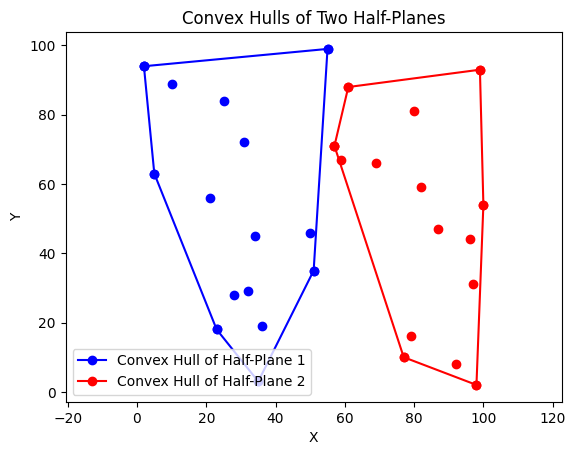

In [25]:
#visualize:
import matplotlib.pyplot as plt

# Separate the x and y coordinates of points in half-plane 1
half_plane1_x = [p[0] for p in half_plane1]
half_plane1_y = [p[1] for p in half_plane1]

# Separate the x and y coordinates of points in half-plane 2
half_plane2_x = [p[0] for p in half_plane2]
half_plane2_y = [p[1] for p in half_plane2]

# Plot the convex hull of half-plane 1 with matching color
hull_half_plane1_x = [p[0] for p in hull_half_plane1]
hull_half_plane1_y = [p[1] for p in hull_half_plane1]
plt.plot(hull_half_plane1_x, hull_half_plane1_y, '-o', color='blue', label='Convex Hull of Half-Plane 1')

# Plot the convex hull of half-plane 2 with matching color
hull_half_plane2_x = [p[0] for p in hull_half_plane2]
hull_half_plane2_y = [p[1] for p in hull_half_plane2]
plt.plot(hull_half_plane2_x, hull_half_plane2_y, '-o', color='red', label='Convex Hull of Half-Plane 2')

# Set the scatter point colors to match the hull colors
plt.scatter(half_plane1_x, half_plane1_y, color='blue')
plt.scatter(half_plane2_x, half_plane2_y, color='red')

# Set the plot title and labels
plt.title('Convex Hulls of Two Half-Planes')
plt.xlabel('X')
plt.ylabel('Y')

# Set the aspect ratio to equal
plt.axis('equal')

# Display the legend
plt.legend()

# Show the plot
plt.show()

..

In [ ]:
def upper_lower(hull1, hull2):
    # Find the x-coordinate that separates the two hulls equally distanced
    x_separator = (max(hull1, key=lambda point: point[0])[0] + min(hull2, key=lambda point: point[0])[0]) / 2

    # Connect all points of one hull to all points of another hull and find the intersection point on the y-axis
    upper_bound_points = []
    lower_bound_points = []
    for point1 in hull1:
        for point2 in hull2:
            if point1[0] != point2[0]:
                slope = (point2[1] - point1[1]) / (point2[0] - point1[0])
                y_intercept = point1[1] - slope * (point1[0] - x_separator)
                if min(point1[0], point2[0]) <= x_separator <= max(point1[0], point2[0]):
                    intersect_point = (x_separator, y_intercept)
                    if point1[1] < point2[1]:
                        upper_bound_points.append(point1)
                        upper_bound_points.append(point2)
                        upper_bound_points.append(intersect_point)
                    else:
                        lower_bound_points.append(point1)
                        lower_bound_points.append(point2)
                        lower_bound_points.append(intersect_point)

    # Sort the points in ascending order of y-coordinate
    upper_bound_points.sort(key=lambda point: point[1])
    lower_bound_points.sort(key=lambda point: point[1])

    # Extract the upper and lower bound points
    upper_bound = (lower_bound_points[-1], upper_bound_points[-1])
    lower_bound = (lower_bound_points[0], upper_bound_points[0])

    return upper_bound, lower_bound
upper_bound, lower_bound=upper_lower(hull_half_plane1,hull_half_plane2)

def merge_half_hulls(hull1, hull2, upper_bound, lower_bound):
    # Find the indices of the upper bound points in the half-hulls
    upper_bound_index_hull1 = hull1.index(upper_bound[0])
    upper_bound_index_hull2 = hull2.index(upper_bound[1])

    # Merge the half-hulls based on the upper bound
    merged_hull = [upper_bound[0]]

    # Merge hull2 until the lower bound is reached
    i = (upper_bound_index_hull2 + 1) % len(hull2)
    while hull2[i] != lower_bound[0]:
        merged_hull.append(hull2[i])
        i = (i + 1) % len(hull2)

    # Add the lower bound of the second half-hull
    merged_hull.append(lower_bound[0])

    # Merge hull1 until the lower bound is reached
    i = upper_bound_index_hull1 - 1
    while hull1[i] != lower_bound[1]:
        merged_hull.append(hull1[i])
        i = (i - 1) % len(hull1)

    # Add the remaining portion of hull1 until the upper bound is reached
    i = (i - 1) % len(hull1)
    while hull1[i] != upper_bound[0]:
        merged_hull.append(hull1[i])
        i = (i - 1) % len(hull1)

    merged_hull.append(upper_bound[0])

    return merged_hull


merged_hull = merge_half_hulls(hull_half_plane1, hull_half_plane2, upper_bound, lower_bound)

##Merge

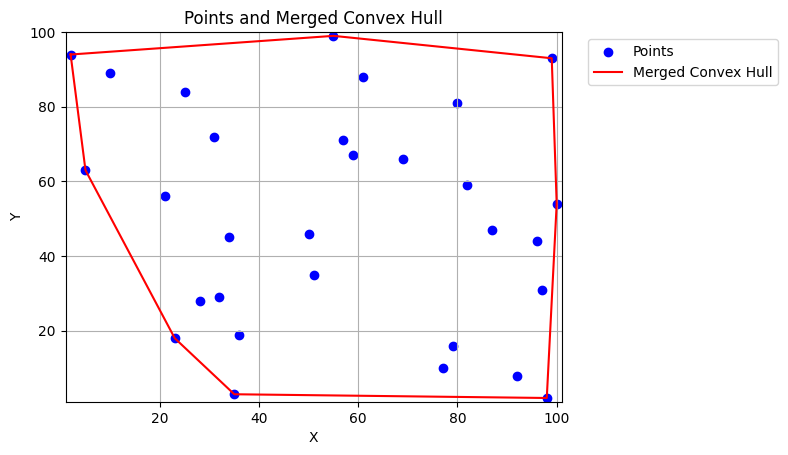

In [30]:


# Extract x and y coordinates from the points
x = [point[0] for point in points]
y = [point[1] for point in points]

# Plot all points
plt.scatter(x, y, color='blue', label='Points')

# Extract x and y coordinates from the merged hull
convex_hull = generate_convex_hull(points)
x_merged = [point[0] for point in convex_hull]
y_merged = [point[1] for point in convex_hull]
plt.plot(x_merged, y_merged, 'r-', label='Merged Convex Hull')

# Set plot limits
plt.xlim(min(x)-1, max(x)+1)
plt.ylim(min(y)-1, max(y)+1)

# Plot the merged convex hull
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Points and Merged Convex Hull')
plt.grid(True)

# Move the legend outside the plot
plt.legend(bbox_to_anchor=(1.04, 1), loc='upper left')

plt.show()

## Resources

https://startupnextdoor.com/computing-convex-hull-in-python/ \
https://www.geeksforgeeks.org/convex-hull-using-divide-and-conquer-algorithm/ \
https://www.youtube.com/watch?v=EzeYI7p9MjU \
https://jayjingyuliu.wordpress.com/2018/01/24/algorithm-two-finger-convex-hull-merging-algorithm/ \
chat GPT